In [1]:
from models import FNN, device
import numpy as np
import torch
import torch.nn as nn
from tqdm import trange
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
dtype = torch.float64

In [30]:
# Try to create an operator able to learn the solution of a very simple ODE

class FNO(nn.Module):
    def __init__(self, modes, latent_width):
        super().__init__()

        self.modes = modes
        self.latent_width = latent_width

        self.enc = nn.Linear(1, self.latent_width, dtype=dtype, device=device)

        self.weights = nn.Parameter(
            (
                torch.randn(self.latent_width, self.latent_width, self.modes, device=device)
                + 1j * torch.randn(self.latent_width, self.latent_width, self.modes, device=device)
            ).to(torch.complex128)
        )

        self.dec = nn.Linear(self.latent_width, 1, dtype=dtype, device=device)

    def fix_dim(self, t):
            if t.dim() == 1:        # (b,)
                t = t.unsqueeze(0).unsqueeze(-1)   # -> (1, b, 1)
            elif t.dim() == 2:      # (a, b)
                t = t.unsqueeze(-1)                # -> (a, b, 1)
            elif t.dim() == 3:      # already correct
                pass
            else:
                raise ValueError(
                    f"Expected tensor with 1, 2, or 3 dims, got {t.dim()}"
                )
            return t

    def sanity_check(self, x, y):
        x = self.fix_dim(x)
        y = self.fix_dim(y)
        assert x.shape[0] == y.shape[0], "Batch size of x and y must match"
        assert x.shape[1] == y.shape[1], "Number of samples in x and y must match"
        assert x.shape[2] == 1, "Input x must have shape [batch, samples, 1]"
        assert y.shape[2] == 1, "Output y must have shape [batch, samples, 1]"
        assert self.modes <= x.shape[1] // 2 + 1, "Number of modes must be less than or equal to half the number of samples plus one (due to rfft)"
        return x, y

    def forward(self, x):
        """
        Here is described the shape of each tensor used in the forward pass.
        x:                  [batch (b), samples (s), 1]
        x_enc:              [b, s, channels_in (n, d)]
        x_ft:               [b, frequencies, n]
        weights (conv):     [n, d, modes (m)]
        x_ift:              [b, s, d]
        x_dec:              [b, s, 1]
        """

        x_enc = self.enc(x)
        x_ft = torch.fft.rfft(x_enc, dim=1)

        # Out-of-place frequency update to keep autograd graph valid.
        x_ft_low = torch.einsum("bmn, ndm -> bmd", x_ft[:, :self.modes, :], self.weights)
        x_ft = torch.cat((x_ft_low, x_ft[:, self.modes:, :]), dim=1)

        x_ift = torch.fft.irfft(x_ft, n=x_enc.shape[1], dim=1)
        x_dec = self.dec(x_ift)

        return x_dec

    def loss(self, gt, pred):
        return torch.mean(torch.mean((gt - pred) ** 2, dim=(1,2)))

    def train_model(self, x_train, y_train, epochs=1000, lr=1e-3, validation_data=None, loss_tracking=False, lr_scheduler=None):
        """
        Trains the model on the provided training data.
        Accepts training inputs with shape (b,), (a, b), or (a, b, c), where:
        - b is the number of samples (e.g., time steps)
        - a is the batch size
        - c is the number of input channels (must be 1 for this model)
        """
        
        x_train, y_train = self.sanity_check(x_train, y_train)
        if validation_data is not None:
            x_val, y_val = validation_data
            x_val, y_val = self.sanity_check(x_val, y_val)
        if loss_tracking:
            train_losses = []
            val_losses = []

        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        epochs = trange(epochs, desc="Training Epoch: ")
        for epoch in epochs:
            if lr_scheduler is not None and epoch == lr_scheduler['step']:
                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr_scheduler['lr']
            pred = self.forward(x_train)
            loss = self.loss(y_train, pred)
            if loss_tracking:
                train_losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if validation_data is not None:
                with torch.no_grad():
                    val_pred = self.forward(x_val)
                    val_loss = self.loss(y_val, val_pred)
                if loss_tracking:
                    val_losses.append(val_loss.item())

            epochs.set_postfix({'train_loss': loss.item(), 'val_loss': val_loss.item() if (validation_data is not None) else 'N/A'})
        if loss_tracking and validation_data is not None:
            return train_losses, val_losses
        elif loss_tracking:
            return train_losses

    def predict(self, x):
        """
        Predict the output for a given input x.
        Accepts inputs with shape (b,), (a, b), or (a, b, c), where:
        - b is the number of samples (e.g., time steps)
        - a is the batch size
        - c is the number of input channels (must be 1 for this model)
        """
        x = self.fix_dim(x)
        with torch.no_grad():
            prediction = self.forward(x)
            return prediction.squeeze(-1).squeeze(0) if prediction.shape[0] == 1 else prediction.squeeze(-1)

In [17]:
# Creating a family of functions based on the sum of 5 omega*cos(omega*t)

samples = 128
batches = 2048
t = torch.linspace(-1, 1, samples, device=device, dtype=dtype)
rand_amplitudes = torch.rand(batches, 5, device=device, dtype=dtype)
x_train_matrix = torch.zeros(batches, samples, device=device, dtype=dtype)
y_train_matrix = torch.zeros(batches, samples, device=device, dtype=dtype)
for i in range(batches):
    c = torch.rand(5, device=device, dtype=dtype)
    x_train_matrix[i] = c[0] * np.pi * torch.cos(t * c[0] *np.pi) + \
                        c[1] *3*np.pi * torch.cos(t * c[1] * 3*np.pi) + \
                        c[2] *6*np.pi * torch.cos(t * c[2] * 6*np.pi) + \
                        c[3] *9*np.pi * torch.cos(t * c[3] * 9*np.pi) + \
                        c[4] *12*np.pi * torch.cos(t * c[4] * 12*np.pi)
    y_train_matrix[i] = torch.sin(t * c[0] * np.pi) + \
                         torch.sin(t * c[1] * 3*np.pi) + \
                         torch.sin(t * c[2] * 6*np.pi) + \
                         torch.sin(t * c[3] * 9*np.pi) + \
                         torch.sin(t * c[4] * 12*np.pi)

x_val = 2 * np.pi * torch.cos(t * 2 * np.pi)
y_val = torch.sin(t * 2 * np.pi)

loss = torch.mean(((y_train_matrix - x_train_matrix) ** 2).mean(dim=(1)))
print(loss.item())

517.5207062100387


In [31]:
model = FNO(modes=32, latent_width=32).to(device=device)
train_losses, val_losses = model.train_model(
    x_train_matrix,
    y_train_matrix,
    epochs=300,
    lr=1e-3,
    validation_data=(x_val, y_val),
    loss_tracking=True,
    lr_scheduler={'step': 150, 'lr': 1e-4}
)

Training Epoch: 100%|██████████| 300/300 [01:14<00:00,  4.00it/s, train_loss=0.895, val_loss=0.0446]


Text(0.5, 1.0, 'Training and Validation Loss')

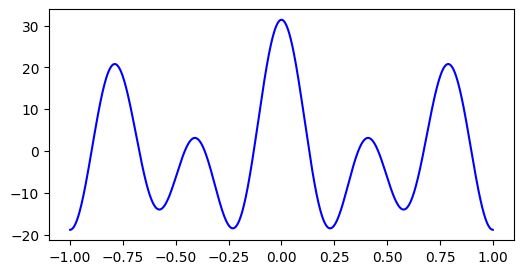

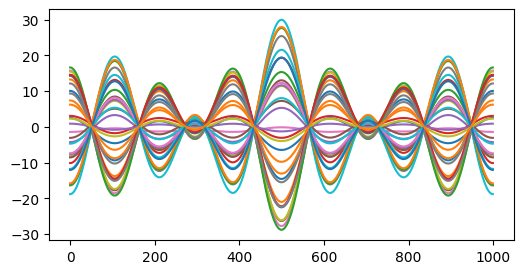

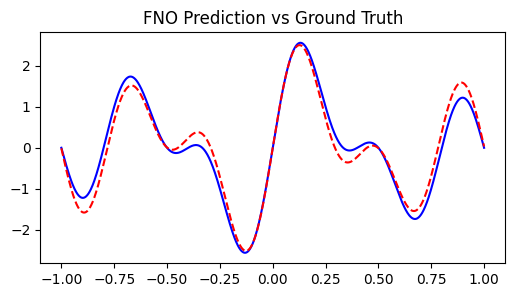

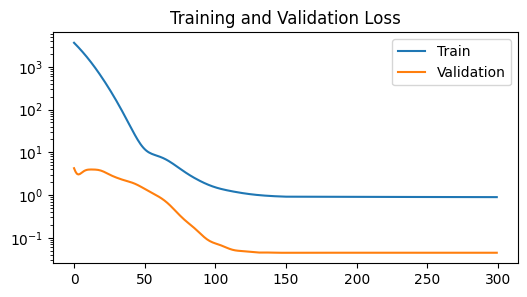

In [33]:
t_test = torch.linspace(-1, 1, 1000, device=device, dtype=dtype)
x_test = 2 * np.pi * torch.cos(t_test * 2 * np.pi) + 3 * np.pi * torch.cos(t_test * 3 * np.pi) + 5 * np.pi * torch.cos(t_test * 5 * np.pi)
x_to_enc = model.fix_dim(x_test)
x_encoded = model.enc(x_to_enc).detach().numpy()
y_test = torch.sin(t_test * 2 * np.pi) + torch.sin(t_test * 3 * np.pi) + torch.sin(t_test * 5 * np.pi)
y_pred = model.predict(x_test)

plt.figure(figsize=(6, 3))
plt.plot(t_test.cpu(), x_test.cpu(), label='Ground Truth', color='blue')

plt.figure(figsize=(6, 3))
plt.plot(x_encoded[0,:,:])

plt.figure(figsize=(6, 3))
plt.plot(t_test.cpu(), y_test.cpu(), label='Ground Truth', color='blue')
plt.plot(t_test.cpu(), y_pred.cpu(), label='FNO Prediction', color='red', linestyle='dashed')
plt.title('FNO Prediction vs Ground Truth')

plt.figure(figsize=(6, 3))
plt.semilogy(train_losses, label='Train')
plt.semilogy(val_losses, label='Validation')
plt.legend()
plt.title('Training and Validation Loss')